# **✔️ [파일] -[Drive에 사본 저장]**

### **🌱 데이터 직접 수집 → 웹 크롤링 이해하기!**

In [ ]:
import requests # 웹사이트에 HTTP 요청을 보내서 웹 페이지의 데이터를 가져오는 라이브러리
from bs4 import BeautifulSoup # HTML 문서를 분석해서 원하는 데이터만 쉽게 찾도록 도와주는 라이브러리
from urllib.parse import quote # 한글을 URL에서 사용할 수 있는 형태로 변환하는 함수

keyword = "왕과 사는 남자"

BASE_URL = "https://search.naver.com/search.naver?where=news&query="

headers = {
    "User-Agent": "Mozilla/5.0"
}

# 검색어 인코딩
encoded_keyword = quote(keyword)

# 첫 페이지 URL
url = f"{BASE_URL}{encoded_keyword}&start=1"

# 요청
res = requests.get(url, headers=headers)
soup = BeautifulSoup(res.text, "html.parser")

# 뉴스 제목 선택
titles = soup.select('a[data-heatmap-target=".tit"]')

# 파일 저장
with open("naver_news_20.txt", "w", encoding="utf-8-sig") as file:
    if not titles:
        print("찾은 기사가 없습니다.")
    else:
        # Ensure we don't go out of bounds if less than 150 titles are found
        num_titles_to_process = min(20, len(titles))
        for i in range(num_titles_to_process):
            title = titles[i].get_text(strip=True)
            print(title)
            file.write(title + "\n")

print("완료! 뉴스 제목 20개 저장됨")

‘왕과 사는 남자’, 1200만 돌파…‘파묘’ 넘었다
‘왕과 사는 남자’ 1200만 관객 돌파…‘파묘’ 넘고 역대 흥행 20위
'왕과 사는 남자', 관객 1200만 곧 돌파
저물 줄 모르는 '왕과 사는 남자' 인기…관객 1200만명 돌파
'왕과 사는 남자' 1200만명 ↑…주말 1300만명 넘는다
'왕과 사는 남자', 개봉 36일째 1200만 명도 넘었다…'파묘' 제쳐
'왕과 사는 남자' 개봉 36일째 1200만명 돌파
'왕과 사는 남자' 관객 1200만명 넘어…'파묘'도 제쳤다
'왕과 사는 남자' 제작사 "표절 주장 사실무근…단호히 대응"
‘왕과 사는 남자’ 표절 주장에 제작사 ‘발칵’…왜? [이런뉴스]
천만영화 ‘왕과 사는 남자’가 표절?…“사실무근, 단호히 대응”
곧 1200만 ‘왕과 사는 남자’에 표절설 제기…제작사 “사실무근”
'왕과 사는 남자' 제작사 "타 저작물 표절한 사실 전혀 없다…단호히 대...
'태극기 휘날리며'도 뛰어넘은 '왕과 사는 남자'
1200만 ‘왕과 사는 남자’ 장항준 감독...인센티브는 얼마?
‘왕과사는남자’ 에디션, 왕사핑 예약 판매
'왕사남' 1200만 대박…장항준, 수십억 돈방석 앉나
"몰입 깨네"…'왕과 사는 남자' 말 많던 '호랑이 CG' 손본다
1200만 '왕과 사는 남자', "옥에 티" 지적받은 호랑이 CG 수정한다
1200만 영화 '왕과 사는 남자' 흥행 감사합니다[★포토]
완료! 뉴스 제목 20개 저장됨


### 🌱 텍스트 분석 코드(워드 클라우드 제작)

In [ ]:
#코랩에서 한글 사용하기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
!pip install konlpy

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,319 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and direc

In [ ]:
from wordcloud import WordCloud #워드클라우드 그리기
from konlpy.tag import Okt  #한글 형태소 분석
from collections import Counter  #단어 빈도수
import matplotlib.pyplot as plt

# 텍스트 파일 불러오기
file_path = '/content/naver_news_20.txt'
with open(file_path, 'r', encoding='utf-8') as f:
    text = f.read()

# 한글 형태소 분석기 초기화
okt = Okt()

# 명사만 추출
nouns = okt.nouns(text)

# 한 글자 단어 제거 (불용어 처리)
words = [n for n in nouns if len(n) > 1]

# 단어 빈도수 계산
word_counts = Counter(words)

# 가장 흔한 단어 50개 출력
display(word_counts.most_common(50))

[('남자', 19),
 ('돌파', 5),
 ('표절', 5),
 ('파묘', 4),
 ('관객', 4),
 ('제작사', 4),
 ('사실', 4),
 ('무근', 3),
 ('단호', 3),
 ('흥행', 2),
 ('개봉', 2),
 ('주장', 2),
 ('대응', 2),
 ('영화', 2),
 ('장항준', 2),
 ('왕사', 2),
 ('호랑이', 2),
 ('역대', 1),
 ('인기', 1),
 ('주말', 1),
 ('명도', 1),
 ('발칵', 1),
 ('뉴스', 1),
 ('천만', 1),
 ('제기', 1),
 ('저작물', 1),
 ('전혀', 1),
 ('태극기', 1),
 ('감독', 1),
 ('인센티브', 1),
 ('얼마', 1),
 ('에디', 1),
 ('예약', 1),
 ('판매', 1),
 ('대박', 1),
 ('방석', 1),
 ('몰입', 1),
 ('지적', 1),
 ('수정', 1),
 ('포토', 1)]

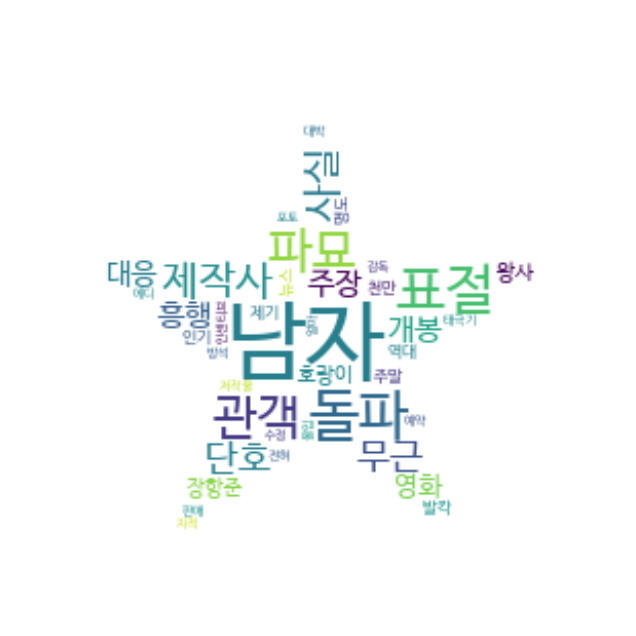

In [ ]:
import matplotlib.font_manager as fm
from PIL import Image
import numpy as np

# 한글 폰트 경로 설정 (이전에 설치한 나눔 폰트)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

# 마스크 이미지 불러오기
mask_image = np.array(Image.open('/content/star.jpg'))

# 워드클라우드 생성
wc = WordCloud(
    font_path=font_path, # 한글 폰트 경로 지정
    background_color='white', # 배경색
    mask=mask_image, # 마스크 이미지 적용
    width=800, # 이미지 너비 (마스크 적용 시 무시될 수 있음)
    height=600, # 이미지 높이 (마스크 적용 시 무시될 수 있음)
    max_words=100, # 최대 단어 수
    colormap='viridis' # 색상 맵
)

# 워드클라우드 생성
wc.generate_from_frequencies(word_counts)

# 시각화
plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()